## Clone repository

In [1]:
# # Clone the repository containing the project code
import sys
import os
repo_dir = 'cell-fuzzy-seg'
if not os.path.exists(repo_dir):
    !git clone --branch homolog https://github.com/Pedro-io/cell-fuzzy-seg.git
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

/content/cell-fuzzy-seg


### Install Dependecies


In [2]:
!pip install -r requirements.txt

In [3]:
from src.pipeline.steps.cellpose_step import CellposeStep
from src.pipeline.steps.rgba_step import RGBAStep
from src.io.output_writer import OutputWriter
from src.data.load.monuseg_dataset import MonusegDataset

Input directory with your images:

In [4]:
from src.data.load.monuseg_dataset import MonusegDataset

data = MonusegDataset(
  dataset_name="monuseg",
  config_key="monuseg_training"
  )

2026-05-03 21:57:07.953 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:104 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations


In [5]:
class SimplePipeline:
    def __init__(self, steps):
        self.steps = steps

    def forward(self, data):
        for step in self.steps:
            data = step(data)
        return data

In [6]:
pipeline = SimplePipeline([
    CellposeStep(),
    RGBAStep()
])

2026-05-03 21:57:48.525 | INFO     | src.pipeline.steps.cellpose_step:__init__:15 - [CellposeStep] Running on GPU


In [7]:
data = pipeline.forward(data[0])

2026-05-03 21:59:05.147 | DEBUG    | src.data.load.monuseg_dataset:_load_image:60 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-05-03 21:59:05.214 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:82 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml
2026-05-03 21:59:05.215 | DEBUG    | src.data.load.monuseg_dataset:_load_image:60 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-05-03 21:59:15.393 | DEBUG    | src.pipeline.steps.rgba_step:_build_rgba:30 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)


In [8]:
print(data.keys())

dict_keys(['id', 'image', 'ground_truth', 'meta', 'segmentation', 'flows', 'styles', 'rgba'])


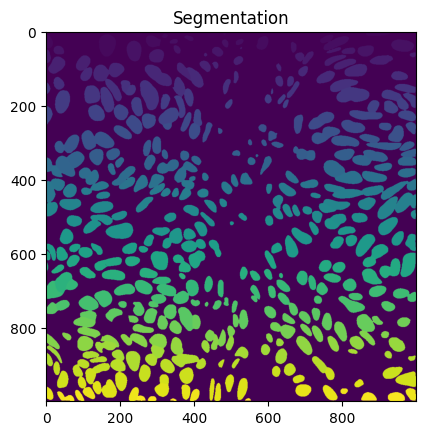

In [9]:
import matplotlib.pyplot as plt

plt.imshow(data["segmentation"])
plt.title("Segmentation")
plt.show()

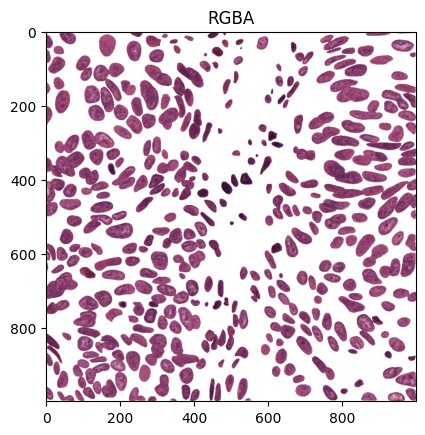

In [10]:
plt.imshow(data["rgba"])
plt.title("RGBA")
plt.show()

In [11]:
writer = OutputWriter("outputs")

writer.save_all(data)
writer.save_rgba(data["id"], data["rgba"])

In [14]:
print(data["image"].dtype, data["image"].min(), data["image"].max())

uint8 8 255


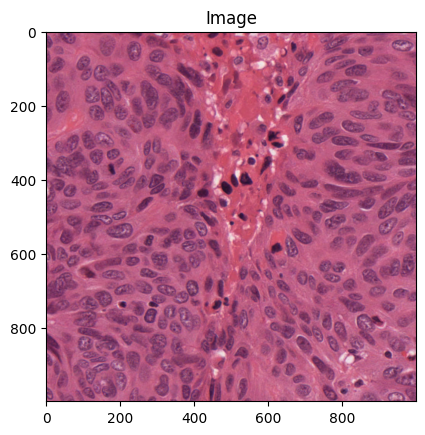

In [15]:
plt.imshow(data["image"])
plt.title("Image")
plt.show()